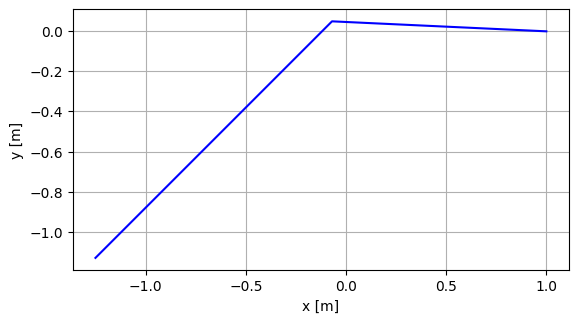

In [ ]:
# @title 磁気力で軌道を作れるか？グラフ

# m2は固定されているものとする(0,0)

import numpy as np
import matplotlib.pyplot as plt

K = 6.33 * (10**4)  # クーロンの法則の定数
# 磁気量
m1 = 4 * (10**-5)
m2 = 4 * (10**-5)

t0 = 0
# m1の初期位置
r0 = np.array([1, 0])
# 初期速度
v0 = np.array([-0.07, 0.05])

t = np.zeros(10000)
t[0] = 0
r1 = np.zeros((10000, 2))
r1[0, :] = r0
v = np.zeros((10000, 2))
v[0, :] = v0

for i in range(9999):
    # 距離
    ri_norm = np.sqrt(r1[i, 0] ** 2 + r1[i, 1] ** 2)
    t[i + 1] = t[i] + 1
    v[i + 1, :] = v[i, :] - K * m1 * m2 / ri_norm
    r1[i + 1, :] = r1[i + 1, :] + v[i, :] * (t[i + 1] - t[i])

plt.plot(r1[:, 0], r1[:, 1], "b")
plt.grid()
plt.gca().set_aspect("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.show()

/tmp/ipykernel_37147/1644413646.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


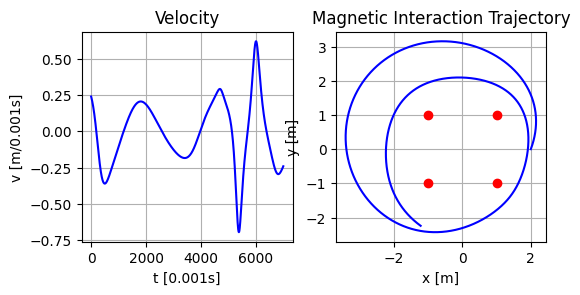

In [1]:
# @title Gemini修正版
import numpy as np
import matplotlib.pyplot as plt

# 定数
K = 6.33 * (10**4)
m1_mag = -24 * (10**-5)  # 磁気量1
m2_mag = 18 * (10**-5)  # 磁気量2
m3_mag = 18 * (10**-5)
m4_mag = 8 * (10**-5)
m5_mag = 2 * (10**-5)
mass = 0.006  # 磁石1の質量 [kg]

dt = 0.005
steps = 7000

# 初期値
r2 = np.array([1.0, 1.0])
r3 = np.array([-1.0, 1.0])
r4 = np.array([-1.0, -1.0])
r5 = np.array([1.0, -1.0])
r1 = np.zeros((steps, 2))
v = np.zeros((steps, 2))
a = np.zeros((steps, 2))
r1[0] = np.array([2.0, 0.0])  # 初期位置
v[0] = np.array([0.3, 0.8])  # 初期速度
a[0] = 0

for i in range(steps - 1):
    # 距離
    r1r2 = np.linalg.norm(r1[i] - r2)
    # 磁気力: F = K * m1 * m2 / r^2
    fmag_r1r2 = K * m1_mag * m2_mag / (r1r2**2)
    fmag_r1r2 = fmag_r1r2 * ((r1[i] - r2) / r1r2)

    r1r3 = np.linalg.norm(r1[i] - r3)
    fmag_r1r3 = K * m1_mag * m3_mag / (r1r3**2)
    fmag_r1r3 = fmag_r1r3 * (r1[i] - r3) / r1r3

    r1r4 = np.linalg.norm(r1[i] - r4)
    fmag_r1r4 = K * m1_mag * m4_mag / (r1r4**2)
    fmag_r1r4 = fmag_r1r4 * (r1[i] - r4) / r1r4

    r1r5 = np.linalg.norm(r1[i] - r5)
    fmag_r1r5 = K * m1_mag * m5_mag / (r1r5**2)
    fmag_r1r5 = fmag_r1r5 * (r1[i] - r5) / r1r5

    # 加速度: a = F / mass
    a[i + 1] = (fmag_r1r2 + fmag_r1r3 + fmag_r1r4 + fmag_r1r5) / mass

    # 速度と位置の更新 (velocity verlet法)
    r1[i + 1] = r1[i] + v[i] * dt + a[i] * (dt**2) / 2
    v[i + 1] = v[i] + (a[i] + a[i + 1]) * dt / 2


def plot(
    r: np.ndarray[np.float64], v: np.ndarray[np.float64], a: np.ndarray[np.float64]
):
    fig = plt.figure(figsize=(6, 6))

    ax1 = fig.add_subplot(2, 2, 1)
    ax1.plot(v[:, 0] * v[:, 1], "b", label="Velocity")
    ax1.set_xlabel("t [0.001s]")
    ax1.set_ylabel("v [m/0.001s]")
    ax1.grid()
    ax1.set_title("Velocity")

    ax2 = fig.add_subplot(2, 2, 2)
    ax2.plot(r1[:, 0], r1[:, 1], "b", label="Magnet 1")
    ax2.plot(r2[0], r2[1], "ro", label="Magnet 2")
    ax2.plot(r3[0], r3[1], "ro", label="Magnet 3")
    ax2.plot(r4[0], r4[1], "ro", label="Magnet 4")
    ax2.plot(r5[0], r5[1], "ro", label="Magnet 5")
    ax2.grid()
    ax2.set_aspect("equal")
    ax2.set_xlabel("x [m]")
    ax2.set_ylabel("y [m]")
    ax2.set_title("Magnetic Interaction Trajectory")

    fig.show()


plot(r1, v, a)

In [ ]:
# @title 周期解を求める
import numpy as np
import matplotlib.pyplot as plt
import itertools
from concurrent.futures import ProcessPoolExecutor
from numba import njit

# 定数
K = 6.33 * (10**4)
r_others = np.array([[1.0, 1.0], [-1.0, 1.0], [-1.0, -1.0], [1.0, -1.0]])

dt = 0.005
steps = 4000

m1_mag = -24 * (10**-5)  # 磁気量1
m_others = np.full(4, 24 * (10**-5))  # 固定された磁石の磁気量
mass = 0.006  # 磁石1の質量 [kg]


# 引数は[x, y, vx, vy]。
# 見つかった場合返り値をそのまま返す。
# 見つからなかった場合len==0の配列を返す。
@njit
def calc(r1_0_and_v_0: np.ndarray[np.float64]) -> np.ndarray[np.float64]:
    r1_0 = np.array(r1_0_and_v_0[0:2])
    v_0 = np.array(r1_0_and_v_0[2:4])

    r1_curr = r1_0
    v_curr = v_0
    a_curr = np.zeros(2)

    for i in range(steps - 1):
        if i > 10:
            # r1[i]がr1[0]と原点を結んだ直線上に存在するか(ポアンカレ断面)
            cross_val = r1_0[0] * r1_curr[1] - r1_0[1] * r1_curr[0]
            if abs(cross_val) < 1e-6:
                # 各状態量が十分に近いか
                diff_r = np.linalg.norm(r1_curr - r1_0)
                diff_v = np.linalg.norm(v_curr - v_0)
                if diff_r < 0.001 and diff_v < 0.001:
                    return (r1_0, v_0)

        diff = r1_curr - r_others
        dist = np.linalg.norm(diff, axis=1, keepdims=True)
        # クーロンの法則
        force_vecs = K * m1_mag * m_others[:, np.newaxis] * diff / dist**3
        total_force = np.sum(force_vecs, axis=0)

        a_next = total_force / mass

        # 速度と位置の更新 (velocity verlet法)
        r1_curr = r1_curr + v_curr * dt + a_curr * (dt**2) / 2
        v_curr = v_curr + (a_curr + a_next) * dt / 2
        a_curr = a_next

    return np.empty(0)


x = np.arange(0.0, 1.5, 0.1)
y = np.arange(0.0, 1.5, 0.1)
vx = np.arange(0.0, 2.0, 0.1)
vy = np.arange(0.0, 2.0, 0.1)

# パラメータの組み合わせを作る
params = itertools.product(x, y, vx, vy)

with ProcessPoolExecutor() as executor:
    results = list(filter(lambda args: args.len() == 4, executor.map(calc, params)))

print(results)

AttributeError: 'tuple' object has no attribute 'len'

In [2]:
# @title 周期解を求める(Gemini修正版)
import numpy as np
import itertools
from concurrent.futures import ProcessPoolExecutor
from numba import njit

K = 6.33 * (10**4)
R_OTHERS = np.array([[1.0, 1.0], [-1.0, 1.0], [-1.0, -1.0], [1.0, -1.0]])
M1_MAG = -24 * (10**-5)
M_OTHERS = np.array([18 * (10**-5), 18 * (10**-5), 8 * (10**-5), 2 * (10**-5)])
MASS = 0.006
DT = 0.005
STEPS = 7000


@njit(cache=True, parallel=True)
def get_acceleration(r1):
    force_total = np.zeros(2)
    for i in range(4):
        diff = r1 - R_OTHERS[i]
        dist = np.sqrt(diff[0] ** 2 + diff[1] ** 2)
        # クーロンの法則: F = K * m1 * m2 * r / r^3
        f_mag = K * M1_MAG * M_OTHERS[i] / (dist**3 + 1e-9)  # ゼロ除算防止
        force_total += f_mag * diff
    return force_total / MASS


@njit(cache=True, parallel=True)
def calc(params):
    r1_0 = np.array([params[0], params[1]])
    v_0 = np.array([params[2], params[3]])

    r_curr = r1_0.copy()
    v_curr = v_0.copy()
    a_curr = get_acceleration(r_curr)

    for i in range(STEPS):
        # Velocity Verlet法
        r_next = r_curr + v_curr * DT + 0.5 * a_curr * (DT**2)
        a_next = get_acceleration(r_next)
        v_next = v_curr + 0.5 * (a_curr + a_next) * DT

        # 周期性の判定 (ある程度時間が経過してから)
        if i > 50:
            # ポアンカレ断面
            cross_val = r1_0[0] * r_next[1] - r1_0[1] * r_next[0]
            if abs(cross_val) < 1e-5:
                diff_r = np.sqrt(np.sum((r_next - r1_0) ** 2))
                diff_v = np.sqrt(np.sum((v_next - v_0) ** 2))
                if diff_r < 0.5 and diff_v < 5.0:
                    return np.array(params)
                else:
                    return np.zeros(4)

        r_curr, v_curr, a_curr = r_next, v_next, a_next

    # 見つからなかった場合ゼロ埋め
    return np.zeros(4)


def main():
    x = np.arange(0.1, 3.1, 0.2)
    y = np.array([0.0])
    vx = np.arange(-0.1, 1.1, 0.2)
    vy = np.arange(0.1, 1.1, 0.2)

    params_list = list(itertools.product(x, y, vx, vy))
    print(f"Total combinations: {len(params_list)}")

    results = []
    with ProcessPoolExecutor() as executor:
        for res in executor.map(calc, params_list, chunksize=100):
            if np.any(res):  # 全て0でなければ（周期解が見つかれば）追加
                results.append(res)

    print("Found periodic solutions (initial states):")
    for r in results:
        print(r)


if __name__ == "__main__":
    main()

Total combinations: 525


Found periodic solutions (initial states):
[0.3 0.  0.3 0.7]
[0.5 0.  0.1 0.5]
